In [1]:
import os
while "honeycomb.py" not in os.listdir():
    os.chdir("..")
    
    
from honeycomb import CSSHoneycomb
import numpy as np
import matplotlib.pyplot as plt

from qubit_containers import Vertex, Edge, Plaquette

In [2]:
s = CSSHoneycomb()
s.plot_surface()

TypeError: float() argument must be a string or a real number, not 'method'

Edges

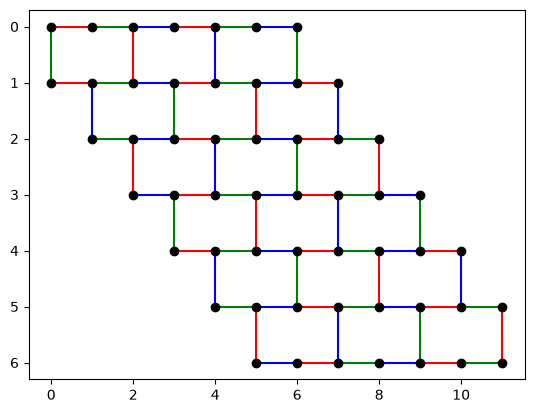

In [ ]:
n_cols = 7
n_rows = 7

coords = []
vertices = []

key = 0

for y in range(n_rows):

    for x in range(n_cols + 1):

        # First row starts at 0 and has one fewer vertex
        if y == 0 and x == n_cols:
            continue

        # Last row also has one fewer vertex
        if y == n_rows - 1 and x == n_cols:
            continue

        xpos = x + y - 1 if y > 0 else x

        v = Vertex(key, (xpos, y))

        vertices.append(v)
        coords.append((xpos, y))

        key += 1

coords = np.array(coords)
edges = []
colours = {
    0 : 'red',
    1 : 'green',
    2 : 'blue'
}

i = 0
for j, v0 in enumerate(vertices):
    x, y = v0.pos

    if y < n_rows-1 and (x+y) % 2 == 0: # vert edge starts from top and works down
        
        v1 = vertices[j + n_cols]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[(x+1)%3], ancilla_key=len(vertices)+i))
        i +=1
        

    if x < n_cols - 1 + y: # horizontal
        
        if y == n_rows - 1 and x == n_cols + n_rows - 3:
            continue
        
        v1 = vertices[j + 1]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[x%3], ancilla_key=len(vertices)+i))
        i +=1

for edge in edges:
    (x0, y0), (x1, y1) = edge.get_coordinates()
    plt.plot((x0, x1), (y0, y1), c=edge.colour, zorder=0)
    plt.gca().yaxis.set_inverted(True)
    
plt.scatter(coords[:,0], coords[:,1], c="black", zorder=1)
plt.gca().yaxis.set_inverted(True)

plt.show()

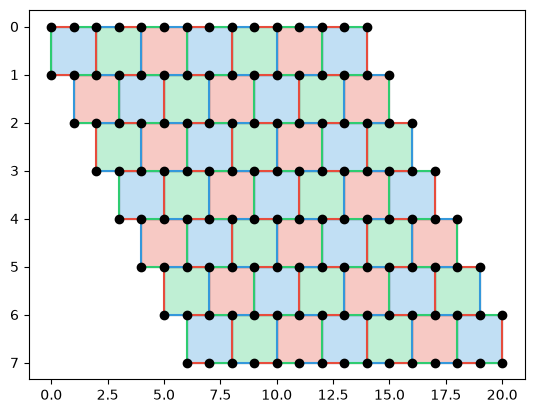

In [ ]:
PALETTE = {
    'red' : '#e74c3c', 
    'green' : '#2ecc71',
    'blue' : '#3498db', 
            }

n_cols = 15
n_rows = 8

# ----------- #
#  vertices   #
# ----------- #

coords = []
vertices = []

key = 0

for y in range(n_rows):

    for x in range(n_cols + 1):

        # First row starts at 0 and has one fewer vertex
        if y == 0 and x == n_cols:
            continue

        # Last row also has one fewer vertex
        if y == n_rows - 1 and x == n_cols:
            continue

        xpos = x + y - 1 if y > 0 else x

        v = Vertex(key, (xpos, y))

        vertices.append(v)
        coords.append((xpos, y))

        key += 1

# ----------- #
#    edges    #
# ----------- #

edges = []

colours = {
    0 : 'red',
    1 : 'green',
    2 : 'blue'
}

i = 0
for j, v0 in enumerate(vertices):
    x, y = v0.pos

    if y < n_rows-1 and (x+y) % 2 == 0: # vert edge starts from top and works down
        
        v1 = vertices[j + n_cols]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[(x+1)%3], ancilla_key=len(vertices)+i))
        i +=1
        

    if x < n_cols - 1 + y: # horizontal
        
        if y == n_rows - 1 and x == n_cols + n_rows - 3:
            continue
        
        v1 = vertices[j + 1]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[x%3], ancilla_key=len(vertices)+i))
        i +=1
        
        
# ----------- #
#  plaquettes #
# ----------- #

vertex_coords = {
    v.get_coordinates(): v
    for v in vertices
}

offsets = [
    (0, 0),
    (1, 0),
    (2, 0),
    (2, 1),
    (1, 1),
    (0, 1)
]

plaquettes = []
i = 0

colours = {
    0 : "blue",
    1 : "red",
    2 : "green"
}

for (x, y), v in vertex_coords.items():

    # Only consider one sublattice of possible plaquette origins
    if (x + y) % 2 == 1:
        continue

    # Get the six required coordinates
    positions = [
        (x + dx, y + dy)
        for dx, dy in offsets
    ]

    # Check whether all six vertices exist
    if not all(pos in vertex_coords for pos in positions):
        continue

    # Get the actual Vertex objects
    p_vertices = [
        vertex_coords[pos]
        for pos in positions
    ]

    plaquettes.append(
        Plaquette(
            key=i,
            colour=colours[(x)%3],
            vertices=p_vertices
        )
    )

    i += 1
        
for p in plaquettes:
    p_coords = np.asarray(p.get_coordinates(ordered=True))
    plt.fill(p_coords[:, 0], p_coords[:, 1], alpha=0.3, facecolor=PALETTE[p.colour], edgecolor="black", zorder=0)


for edge in edges:
    (x0, y0), (x1, y1) = edge.get_coordinates()
    plt.plot((x0, x1), (y0, y1), c=PALETTE[edge.colour], zorder=1)
    plt.gca().yaxis.set_inverted(True)

coords = np.array(coords)
plt.scatter(coords[:,0], coords[:,1], c="black", zorder=2)
plt.gca().yaxis.set_inverted(True)

plt.show()